# AG-HYPOPT · Trial 16

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Fifteen trials. Best: **trial_13** `cvm_fwhm` **0.0733** (sw 0.1910). The low-sw family map is now nearly
complete and the verdict is stable: at matched sw, `cvm_fwhm` (0.073-0.080) beats the KDE control
(0.0803-0.0866 across its three sw points), while the rest sit above it (`w1_2d` 0.0849, `kde` 0.0830-0.0866,
`w1_fwhm` 0.0923, `energy_2d` 0.1021). Trial_15 confirmed KDE does **not** improve at the `cvm_fwhm` basin
sw, so the win is the loss form. The one remaining gap in the matrix is `mmd_2d` at low sw (it has only
been run at sw 0.4331 -> 0.1833). No divergences. Phase `trials` (15/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_16'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (15/5 trials)
ID |     ei | params
 1 | 3.1999 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.20784077997388833}
 2 | 2.3440 | {"loss_family": "mmd_2d", "sigma_weight": 0.20285705384738964}
 3 | 2.6454 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.24094244675394338}
 4 | 2.3081 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.6956239148985941}
 5 | 1.8755 | {"loss_family": "w1_2d", "sigma_weight": 0.2051615272124005}
 6 | 3.0025 | {"loss_family": "cvm_fwhm", "sigma_weight": 0.21424786556376302}
 7 | 0.6331 | {"loss_family": "mmd_2d", "sigma_weight": 0.16894144088877575}
 8 | 2.0139 | {"loss_family": "energy_2d", "sigma_weight": 0.19816166823876125}
 9 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.38474151186552197}
10 |      - | {"loss_family": "kde", "sigma_weight": 0.7694150538287144}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

EI is again dominated by `cvm_fwhm` in the basin (candidates 1, 6, 3), which would add more of the same
confirmation. The campaign has one structural blank left: `mmd_2d` has only ever been run at high sw
(0.4331 -> 0.1833), so it is the only family whose low-sw behaviour is unknown. Candidate 2
(`mmd_2d`, sw 0.2029, ei 2.3440) fills that blank and lets the final report state the family x sw
matrix without a hole. With the leader already settled, closing a coverage gap is worth more than a
seventh `cvm_fwhm` re-run.

I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'mmd_2d', 'sigma_weight': 0.20285705384738964}
Running  1nW Trans05 ... 

μ 9.39 -> 5.83 | γ 8.5 -> 2.82 | NLL -2.49


Running  1nW Trans20 ... 

μ 17.32 -> 33.68 | γ 8.5 -> 5.11 | NLL 0.27


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 46.16 | γ 14.1 -> 13.79 | NLL -3.76


Running 3nW Trans100 ... 

μ 175.71 -> 65.68 | γ 14.1 -> 13.48 | NLL -3.34



Total: 7.8 min


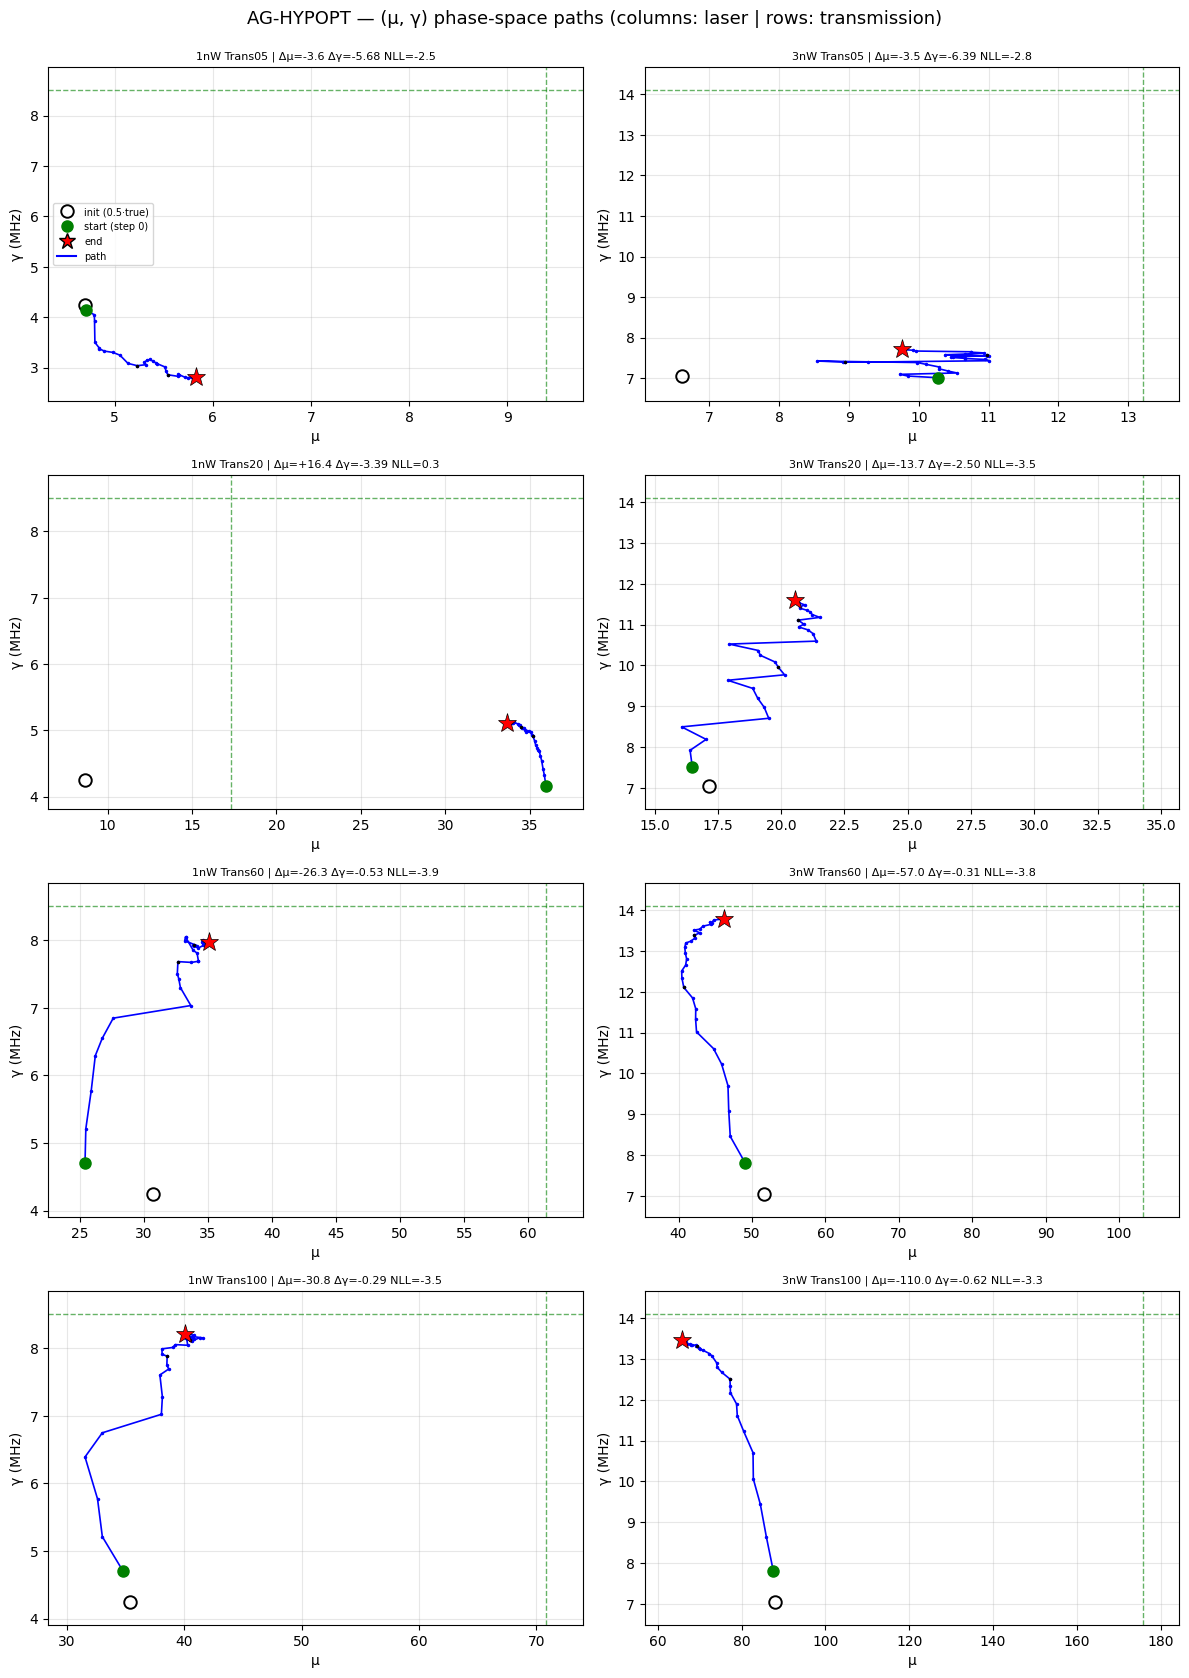

trial finished in 7.8 min
objective = 0.1755 ± 0.0577
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.83   -37.9 |     8.50    2.82   -66.9
1nW Trans20       17.32   33.68   +94.5 |     8.50    5.11   -39.8
1nW Trans60       61.37   35.05   -42.9 |     8.50    7.97    -6.2
1nW Trans100       70.82   40.05   -43.4 |     8.50    8.21    -3.5
3nW Trans05       13.20    9.75   -26.1 |    14.10    7.71   -45.3
3nW Trans20       34.28   20.56   -40.0 |    14.10   11.60   -17.7
3nW Trans60      103.20   46.16   -55.3 |    14.10   13.79    -2.2
3nW Trans100      175.71   65.68   -62.6 |    14.10   13.48    -4.4

weighted objective (T-graded, cap=1.0) = 0.1755 | diverged cells: 0
μ: RMSE 46.743 (rel 54.0%, bias -28.564) | γ: RMSE 3.386 (rel 32.6%, bias -2.464)


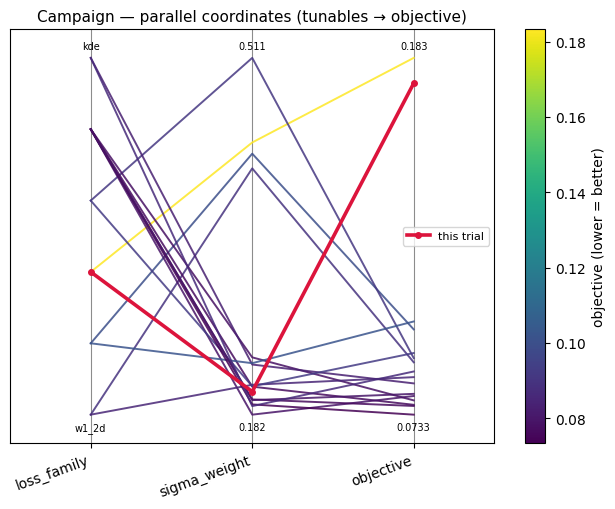

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'mmd_2d', sigma_weight: 0.2029}` (candidate 2). Trial time
7.8 min, objective **0.1755 +/- 0.0577**, **0 diverged cells**. Like its high-sw run (0.1833 at sw
0.4331), this is far worse than everything else; the low-sw region does nothing for MMD.

**Per-cell behaviour.** Classically mu-heavy failure (as in trial_03):

- 1nW Trans05: mu -37.9 %, gamma 8.5 -> 2.82 (-66.9 %).
- 1nW Trans20: mu 17.32 -> 33.68 (**+94.5 %**, near-doubling).
- 1nW Trans60 / Trans100: mu -42.9 % / -43.4 %, gamma -6.2 % / -3.5 %.
- 3nW Trans05 / Trans20: mu -26.1 % / -40.0 %, gamma -45.3 % / -17.7 %.
- 3nW Trans60 / Trans100: mu -55.3 % / -62.6 % (worst), gamma -2.2 % / -4.4 %.

**Aggregates.** mu: RMSE 46.74 (rel 54.0 %), bias -28.56; gamma: RMSE 3.39 (rel 32.6 %), bias -2.46.

**The family x sw matrix is now complete.** At low sw (~0.18-0.24): `cvm_fwhm` 0.073-0.080 (best),
`kde` 0.083-0.087, `w1_2d` 0.0849, `w1_fwhm` 0.0923, `energy_2d` 0.1021, `mmd_2d` 0.1755. At high sw
(~0.41-0.51): `kde` 0.0803 (reference), `w1_2d` 0.0895, `w1_fwhm` 0.0908, `energy_2d` 0.0996,
`mmd_2d` 0.1833. Only `cvm_fwhm` ever beats the KDE control.

**Summary:** `mmd_2d` at sw 0.2029 gives 0.1755, essentially its high-sw value (0.1833), so MMD is
sw-insensitive and by far the worst; this closes the family x sw matrix and leaves `cvm_fwhm` the only
family under the control.
**Key insight:** MMD's failure is a pure loss-form property (0.1755 low-sw vs 0.1833 high-sw), unaffected
by `sigma_weight` - unlike `cvm_fwhm`, whose low-sw improvement is what carries the campaign win.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none - loss-FORM comparison inside the pre-authorized knob.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'mmd_2d at sigma_weight 0.2029 gives 0.1755, essentially its high-sw value (0.1833), so MMD is sw-insensitive and by far the worst; this closes the family x sw matrix with cvm_fwhm the only family under the control.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'MMD failure is a pure loss-form property (0.1755 low-sw vs 0.1833 high-sw), unaffected by sigma_weight - unlike cvm_fwhm, whose low-sw improvement is what carries the campaign win.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_16 | current best: trial_13


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_17.ipynb. Open it and follow its cells from the top.
